# Recherche des profils "sous-cotés" de moins de 24 ans

### Je cherche un joueur évoluant dans des championnats "accessibles" (Belgique, Pays-Bas, Autriche, Scandinavie), avec un fort volume de tirs et d'activité au pressing.

Je vais simuler un dataset brut contenant les statistiques de 500 attaquants évoluant dans des championnats de "Tier 2" (Eredivisie, Jupiler Pro League, Bundesliga Autrichienne, etc.)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

np.random.seed(42)

n_players = 500
leagues = ['Eredivisie', 'Jupiler Pro League', 'Austrian Bundesliga', 'Superligaen', 'Eliteserien']
teams = [f'Team_{i}' for i in range(1, 51)]

data = {
    'Player': [f'Player_{i}' for i in range(n_players)],
    'Age': np.random.randint(17, 32, n_players),
    'League': np.random.choice(leagues, n_players),
    'Minutes_Played': np.random.randint(200, 3000, n_players),
    'Goals': np.random.poisson(8, n_players),
    'Assists': np.random.poisson(3, n_players),
    'Shots': np.random.poisson(40, n_players),
    'xG': np.abs(np.random.normal(9, 3, n_players)),
    'Pressures': np.random.normal(150, 40, n_players),
    'Successful_Dribbles': np.random.poisson(15, n_players)
}

df = pd.DataFrame(data)

df.loc[df['Player'] == 'Player_42', ['Age', 'Goals', 'xG', 'Shots', 'Pressures']] = [21, 11, 14.5, 75, 210]
df.head()

,Player,Age,League,Minutes_Played,Goals,Assists,Shots,xG,Pressures,Successful_Dribbles
0,Player_0,23,Jupiler Pro League,2842,13,1,50,5.749455,152.673930,15
1,Player_1,20,Eredivisie,2672,4,2,48,10.982692,186.083081,14
2,Player_2,29,Eliteserien,2860,4,4,47,9.300578,136.108370,10
3,Player_3,31,Superligaen,1741,2,3,36,15.804184,111.570829,17
4,Player_4,27,Jupiler Pro League,2939,8,4,36,11.406494,117.788049,24


Je dispose maintenant d'un DataFrame brut df. J'y ai inséré artificiellement une "pépite" (le Player_42) qui performe bien, pour vérifier si mon analyse future sera capable de le détecter. Les données sont brutes : il y a des différences énormes de temps de jeu, ce qui rend la comparaison directe (Buts total vs Buts total) impossible et biaisée -> On ne recrute pas sur des totaux, mais sur des moyennes par 90 minutes

## Filtrage

Je ne garde que les joueurs ayant joué au moins 900 minutes (un échantillon représentatif) et ayant moins de 24 ans. Je crée des métriques par 90min et une métrique de "Finishing" (Différence entre Buts et xG) pour voir qui surperforme ou sous-performe statistiquement.

In [12]:
df_filtered = df[(df['Minutes_Played'] >= 900) & (df['Age'] <= 24)].copy()

df_filtered['Goals_p90'] = df_filtered['Goals'] / (df_filtered['Minutes_Played'] / 90)
df_filtered['xG_p90'] = df_filtered['xG'] / (df_filtered['Minutes_Played'] / 90)
df_filtered['Shots_p90'] = df_filtered['Shots'] / (df_filtered['Minutes_Played'] / 90)
df_filtered['Pressures_p90'] = df_filtered['Pressures'] / (df_filtered['Minutes_Played'] / 90)

df_filtered['Finishing_Overperformance'] = df_filtered['Goals'] - df_filtered['xG']

df_filtered = df_filtered.sort_values(by='xG_p90', ascending=False)

df_filtered[['Player', 'Age', 'League', 'Goals_p90', 'xG_p90', 'Finishing_Overperformance']].head(10)

,Player,Age,League,Goals_p90,xG_p90,Finishing_Overperformance
468,Player_468,18,Austrian Bundesliga,0.990099,1.624576,-6.408222
377,Player_377,24,Eredivisie,1.344622,1.249961,1.055992
391,Player_391,18,Jupiler Pro League,0.387097,1.241977,-8.833764
488,Player_488,17,Superligaen,0.526316,1.182927,-7.485373
42,Player_42,21,Austrian Bundesliga,0.863874,1.138743,-3.500000
236,Player_236,17,Eliteserien,0.654886,1.074543,-4.485666
280,Player_280,18,Eredivisie,0.743802,1.003119,-2.789102
347,Player_347,19,Eliteserien,0.537849,0.998383,-5.137512
54,Player_54,19,Eredivisie,0.805369,0.975879,-2.540598
167,Player_167,24,Eredivisie,1.065089,0.974510,1.020515


J'ai réduit ma liste de 500 à un nombre plus restreint de cibles pertinentes. Le tri par xG_p90 me permet de voir les joueurs qui se procurent le plus d'occasions, indépendamment de leur réussite actuelle.

## Visualisation

Je vais visualiser la relation entre les xG et les Buts réels. L'objectif est d'identifier deux types de profils :

Les élites : En haut à droite (Beaucoup d'occasions, beaucoup de buts). Souvent trop chers.

Les sous-côtés : En bas à droite (Beaucoup d'occasions, peu de buts). Ce sont des joueurs qui se mettent dans de bonnes positions mais manquent de réussite en ce moment. C'est la cible idéale pour un club qui n'a pas forcément les moyens d'acheter des joueurs élites.

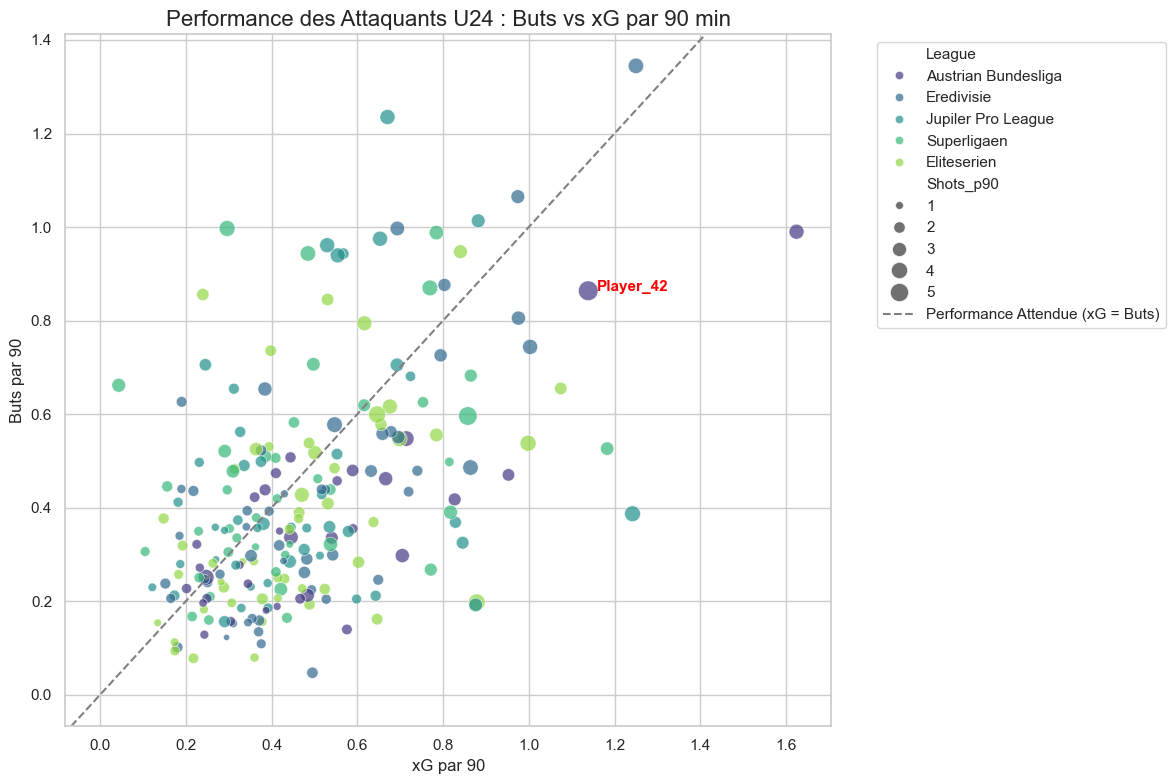

In [13]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_filtered, 
    x='xG_p90', 
    y='Goals_p90', 
    size='Shots_p90', 
    hue='League', 
    sizes=(20, 200), 
    alpha=0.7,
    palette='viridis'
)

plt.axline((0, 0), slope=1, color='gray', linestyle='--', label='Performance Attendue (xG = Buts)')

target_player = df_filtered[df_filtered['Player'] == 'Player_42'].iloc[0]
plt.text(
    target_player['xG_p90'] + 0.02, 
    target_player['Goals_p90'], 
    target_player['Player'], 
    fontsize=11, 
    fontweight='bold', 
    color='red'
)

plt.title('Performance des Attaquants U24 : Buts vs xG par 90 min', fontsize=16)
plt.xlabel('xG par 90', fontsize=12)
plt.ylabel('Buts par 90', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Le graphique me permet d'isoler visuellement les profils. Les joueurs situés sous la ligne pointillée sont ceux qui marquent moins que ce qu'ils devraient (sous-performance). Si un joueur a un xG/90 élevé (vers la droite) mais est sous la ligne, c'est une anomalie : c un joueur qui se procure beaucoup de grosses occasions mais qui tout de mm sous-performe.


 J'ai mis en évidence le Player_42 qui semble avoir un volume de jeu (taille du point = tirs) et une qualité d'occasions très élevés.

## Analyse détaillée du profil

Je vais comparer son profil (j42) à la moyenne des attaquants de mon dataset. Je vais utiliser un Radar Chart utilisant des percentiles.

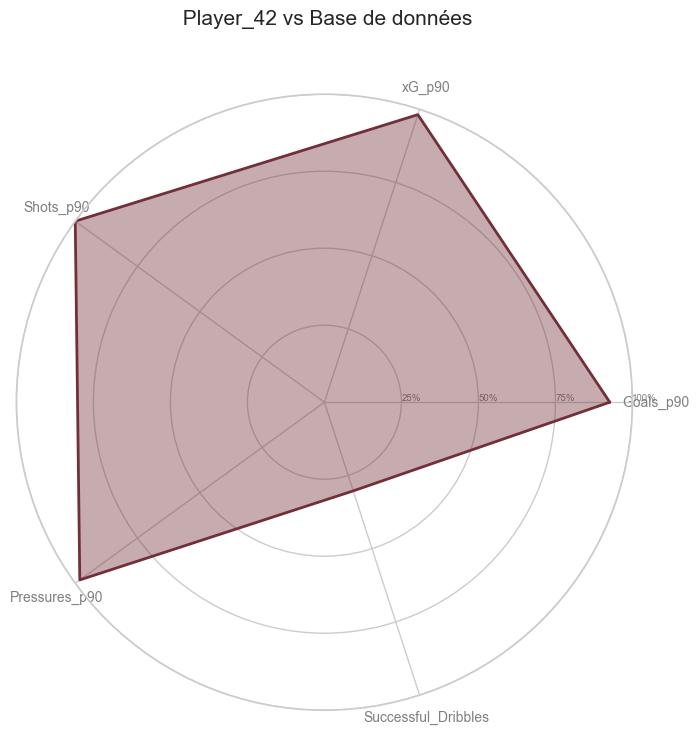

In [14]:
def get_percentile_rank(player_id, df, features):
    player_stats = df[df['Player'] == player_id][features].iloc[0]
    percentiles = []
    for feature in features:
        rank = df[feature].rank(pct=True)[df['Player'] == player_id].iloc[0]
        percentiles.append(rank * 100) 
    return percentiles

features = ['Goals_p90', 'xG_p90', 'Shots_p90', 'Pressures_p90', 'Successful_Dribbles']
values = get_percentile_rank('Player_42', df_filtered, features)
values += values[:1] 

angles = [n / float(len(features)) * 2 * pi for n in range(len(features))]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

plt.xticks(angles[:-1], features, color='grey', size=10)
ax.set_rlabel_position(0)
plt.yticks([25, 50, 75, 100], ["25%", "50%", "75%", "100%"], color="grey", size=7)
plt.ylim(0, 100)

ax.plot(angles, values, linewidth=2, linestyle='solid', color='#722f37') # Couleur TFC
ax.fill(angles, values, '#722f37', alpha=0.4)

plt.title(f" Player_42 vs Base de données", size=15, y=1.1)
plt.show()

Ce radar confirme le profil du Player_42.

Points forts : Il est dans le top percentile pour les Tirs et les Pressions.

Points d'attention : Son percentile de buts est légèrement inférieur à son percentile d'xG : il manque un peu de réussite actuellement.